# 🧠 Autoencoder para Reducción de Ruido en Imágenes (MNIST)

En este proyecto se implementa un **Autoencoder Convolucional** utilizando TensorFlow/Keras para eliminar ruido en imágenes del dataset MNIST.

## 🎯 Objetivo
Entrenar un modelo capaz de reconstruir imágenes limpias a partir de versiones con ruido gaussiano.

## 🧩 ¿Qué es un Autoencoder?
Un Autoencoder es una red neuronal que aprende a:
- Comprimir datos (Encoder)
- Reconstruir datos (Decoder)

En este caso, aprende a eliminar ruido en imágenes.

## 📊 Dataset
Se utiliza el dataset MNIST:
- 70,000 imágenes de dígitos (0–9)
- Tamaño: 28x28
- Escala de grises

## 📦 Importación de librerías

In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

## 📥 Carga y preprocesamiento de datos

Se carga el dataset MNIST y se normalizan los valores de píxeles al rango [0,1] para mejorar el entrenamiento del modelo.

In [40]:
# Cargar y preprocesar los datos MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


## 🔊 Generación de ruido gaussiano

Se añade ruido gaussiano a las imágenes para simular datos corruptos.
El modelo aprenderá a reconstruir la imagen original a partir de estas versiones ruidosas.

In [41]:
# Añadir ruido gaussiano a las imágenes
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## 🏗️ Construcción del Autoencoder

El modelo está compuesto por:
- 🔻 Encoder: reduce la dimensionalidad
- 🔺 Decoder: reconstruye la imagen

Se utilizan capas convolucionales para capturar patrones espaciales.

In [42]:
# Construcción del Autoencoder
input_img = layers.Input(shape=(28, 28, 1))


In [43]:
# Codificador
x = layers.Conv2D(32, (3, 3), activation='relu',
padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

In [44]:
# Decodificador
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid',
padding='same')(x)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Entrenamiento del Autoencoder
autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=128,
validation_data=(x_test_noisy, x_test))

2026-03-16 22:59:14.871130: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 141ms/step - loss: 0.1147 - val_loss: 0.1140
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 140ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 136ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 12/20
469/469

## 📊 Visualización de resultados

Se comparan:
1. Imagen original
2. Imagen con ruido
3. Imagen reconstruida por el modelo

In [45]:
def plot_results(original, noisy, reconstructed, n=10):
    plt.figure(figsize=(20, 6))
    
    for i in range(n):
        # Original
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        
        # Noisy
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        
        # Reconstructed
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    
    plt.show()

## 🔍 Evaluación del modelo

Se generan predicciones sobre el conjunto de prueba para evaluar la capacidad del modelo de eliminar ruido.

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


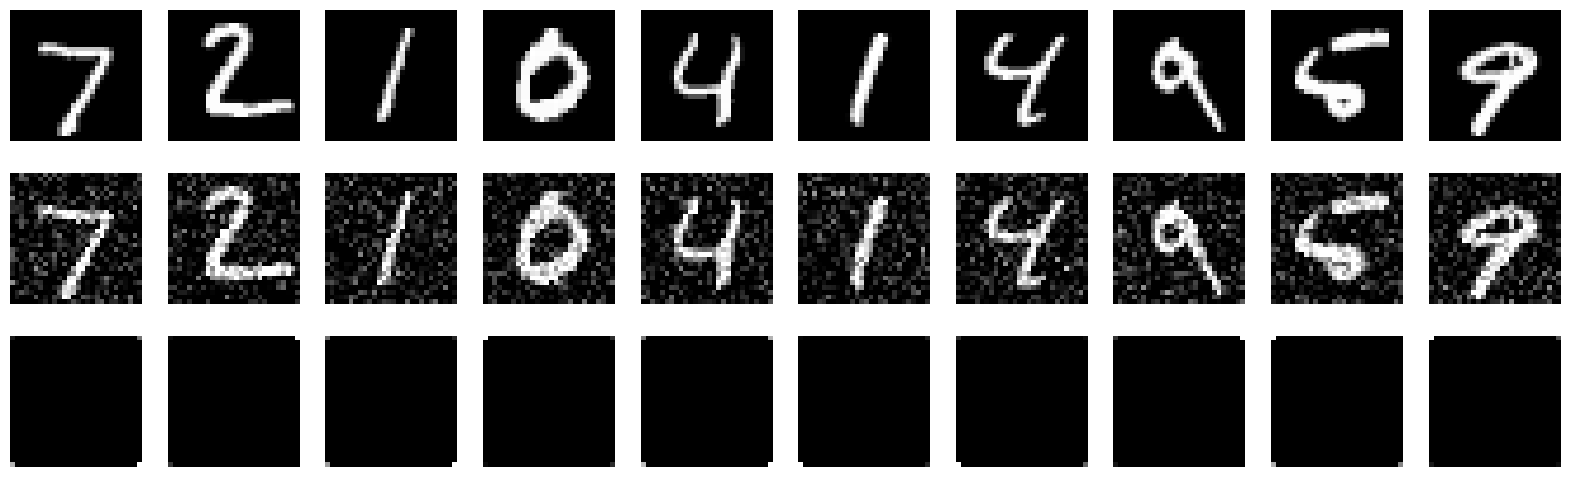

In [46]:
decoded_imgs = autoencoder.predict(x_test_noisy)

plot_results(x_test, x_test_noisy, decoded_imgs)

# 🎨 Generative Adversarial Network (GAN) para Generación de Dígitos - MNIST

En este proyecto se implementa una **GAN (Generative Adversarial Network)** utilizando PyTorch para generar imágenes sintéticas de dígitos escritos a mano.

## 🎯 Objetivo
Entrenar un modelo capaz de generar imágenes realistas a partir de ruido aleatorio.

## 🧩 ¿Qué es una GAN?
Una GAN consta de dos redes neuronales:

- 🎨 Generador: crea imágenes falsas
- 🕵️ Discriminador: distingue entre imágenes reales y falsas

Ambos modelos compiten en un juego tipo "minimax".

## ⚔️ Idea clave
- El Generador intenta engañar al Discriminador
- El Discriminador intenta no ser engañado

Esto mejora progresivamente la calidad de las imágenes generadas.

## 📦 Importación de librerías

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## 📥 Preparación del dataset MNIST

Se normalizan las imágenes al rango [-1, 1], necesario porque el Generador usa función Tanh.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:02<00:00, 4.89MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 357kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.87MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 385kB/s]


## 🎨 Definición del Generador

El Generador transforma un vector de ruido aleatorio en una imagen.

Entrada: vector de 100 dimensiones  
Salida: imagen de 28x28

In [3]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(True),
            
            nn.Linear(256, 512),
            nn.ReLU(True),
            
            nn.Linear(512, 1024),
            nn.ReLU(True),
            
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)

## 🕵️ Definición del Discriminador

El Discriminador clasifica imágenes como:
- 1 → real
- 0 → falsa

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 28 * 28))

## ⚙️ Inicialización de modelos y optimizadores

In [5]:
generator = Generator()
discriminator = Discriminator()

criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002)

## 🏋️ Entrenamiento de la GAN

El entrenamiento ocurre en dos fases:

1. Entrenar el Discriminador
2. Entrenar el Generador

In [6]:
num_epochs = 50

for epoch in range(num_epochs):
    for real_images, _ in dataloader:
        
        batch_size = real_images.size(0)
        
        # Etiquetas
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # ---------------------
        # 🕵️ Entrenar Discriminador
        # ---------------------
        
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, 100)
        fake_images = generator(noise)

        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        optimizer_d.zero_grad()
        d_loss.backward()
        optimizer_d.step()

        # ---------------------
        # 🎨 Entrenar Generador
        # ---------------------
        
        noise = torch.randn(batch_size, 100)
        fake_images = generator(noise)

        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)

        optimizer_g.zero_grad()
        g_loss.backward()
        optimizer_g.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]  D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

Epoch [1/50]  D Loss: 0.0634, G Loss: 5.6024
Epoch [2/50]  D Loss: 0.7436, G Loss: 14.9527
Epoch [3/50]  D Loss: 3.4670, G Loss: 1.0029
Epoch [4/50]  D Loss: 0.1296, G Loss: 5.4512
Epoch [5/50]  D Loss: 0.5867, G Loss: 5.4051
Epoch [6/50]  D Loss: 0.2732, G Loss: 6.0212
Epoch [7/50]  D Loss: 0.1758, G Loss: 3.4431
Epoch [8/50]  D Loss: 0.1807, G Loss: 5.0919
Epoch [9/50]  D Loss: 0.0704, G Loss: 4.9194
Epoch [10/50]  D Loss: 0.2720, G Loss: 4.9308
Epoch [11/50]  D Loss: 0.0916, G Loss: 5.0605
Epoch [12/50]  D Loss: 0.0466, G Loss: 5.8925
Epoch [13/50]  D Loss: 0.3304, G Loss: 5.7875
Epoch [14/50]  D Loss: 0.2507, G Loss: 3.9182
Epoch [15/50]  D Loss: 0.6847, G Loss: 3.5417
Epoch [16/50]  D Loss: 0.2512, G Loss: 5.4617
Epoch [17/50]  D Loss: 0.4315, G Loss: 3.4029
Epoch [18/50]  D Loss: 0.6011, G Loss: 2.0083
Epoch [19/50]  D Loss: 0.4592, G Loss: 4.0183
Epoch [20/50]  D Loss: 0.3302, G Loss: 3.1807
Epoch [21/50]  D Loss: 0.5250, G Loss: 3.0763
Epoch [22/50]  D Loss: 0.3293, G Loss: 3.4

## 🧠 ¿Qué está pasando realmente?

- El Discriminador aprende a distinguir real vs falso
- El Generador aprende a engañar al Discriminador
- Ambos mejoran simultáneamente

Esto crea un equilibrio dinámico.

## 🖼️ Visualización de imágenes generadas

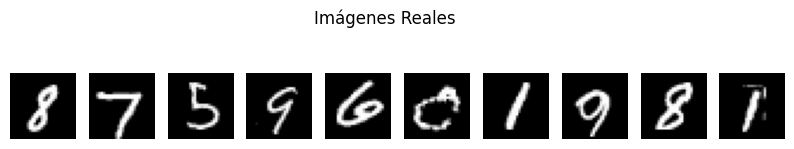

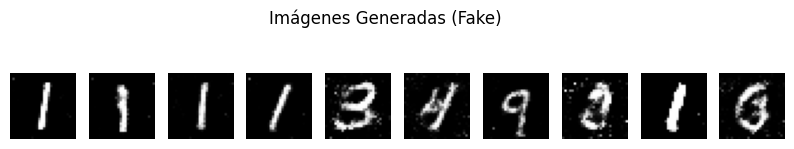

In [11]:
real_images, _ = next(iter(dataloader))

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(real_images[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("Imágenes Reales")
plt.show()

noise = torch.randn(10, 100)
fake_images = generator(noise).detach()

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(fake_images[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("Imágenes Generadas (Fake)")
plt.show()

# Conditional GAN (cGAN) - Generación de Dígitos Controlados

En este proyecto se implementa una Conditional GAN (cGAN), una variante de las GANs que permite generar imágenes condicionadas por etiquetas.

A diferencia de una GAN tradicional, donde el generador produce datos aleatorios, en una cGAN se puede controlar la salida, por ejemplo, generar un número específico (0–9).

Se utiliza el dataset MNIST, que contiene imágenes de dígitos escritos a mano.

## Carga del Dataset MNIST

In [26]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

El dataset MNIST contiene imágenes de tamaño 28x28 en escala de grises. 
Se normalizan en el rango [-1, 1] para mejorar el entrenamiento de la red.

## Generador (Generator)

In [27]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10, 10)

        self.model = nn.Sequential(
            nn.Linear(110, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat((noise, label_input), -1)
        return self.model(x)

## Discriminador (Discriminator)

In [28]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10, 10)

        self.model = nn.Sequential(
            nn.Linear(794, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_input = self.label_emb(labels)
        x = torch.cat((img, label_input), -1)
        return self.model(x)

## Entrenamiento de la cGAN

In [31]:
generator = Generator()
discriminator = Discriminator()

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

epochs = 10

for epoch in range(epochs):
    for imgs, labels in dataloader:
        imgs = imgs.view(imgs.size(0), -1)

        real = torch.ones(imgs.size(0), 1)
        fake = torch.zeros(imgs.size(0), 1)

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(imgs.size(0), 100)
        gen_labels = torch.randint(0, 10, (imgs.size(0),))

        gen_imgs = generator(z, gen_labels)

        g_loss = criterion(discriminator(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        # Train Discriminator
        # ---------------------
        real_loss = criterion(discriminator(imgs, labels), real)
        fake_loss = criterion(discriminator(gen_imgs.detach(), gen_labels), fake)

        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

    print(f"Epoch {epoch} | D Loss: {d_loss.item()} | G Loss: {g_loss.item()}")

Epoch 0 | D Loss: 0.2285917103290558 | G Loss: 2.1956944465637207
Epoch 1 | D Loss: 0.13159021735191345 | G Loss: 2.4148807525634766
Epoch 2 | D Loss: 0.052397698163986206 | G Loss: 4.518805027008057
Epoch 3 | D Loss: 0.08062426745891571 | G Loss: 5.1262407302856445
Epoch 4 | D Loss: 0.06218372657895088 | G Loss: 4.489469051361084
Epoch 5 | D Loss: 0.053778693079948425 | G Loss: 6.77992582321167
Epoch 6 | D Loss: 0.00662481551989913 | G Loss: 8.710025787353516
Epoch 7 | D Loss: 0.020884135738015175 | G Loss: 3.9598588943481445
Epoch 8 | D Loss: 0.20974303781986237 | G Loss: 5.416198253631592
Epoch 9 | D Loss: 0.09291002154350281 | G Loss: 4.065398216247559


## Visualización de resultados

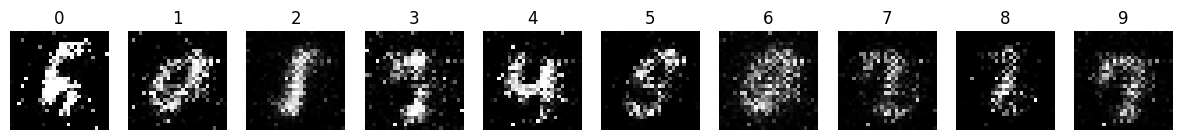

In [32]:
import matplotlib.pyplot as plt

z = torch.randn(10, 100)
labels = torch.arange(0, 10)

gen_imgs = generator(z, labels).detach().numpy()

fig, axs = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axs[i].imshow(gen_imgs[i].reshape(28, 28), cmap='gray')
    axs[i].set_title(f"{i}")
    axs[i].axis('off')

plt.show()